# Small inspection example — three-stage simulation pipeline

Tiny end-to-end run of the world / speaker / listener pipeline so we can eyeball the outputs and a few sanity-check plots before scaling up.

## 1. Setup

In [197]:
from joblib import Parallel, delayed, cpu_count
import os

def get_pid(_):
    return os.getpid()

n_jobs = -1
pids = Parallel(n_jobs=n_jobs)(delayed(get_pid)(i) for i in range(20))

print("Requested n_jobs:", n_jobs)
print("joblib.cpu_count():", cpu_count())
print("Actual workers used:", len(set(pids)))

Requested n_jobs: -1
joblib.cpu_count(): 11
Actual workers used: 5


In [198]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]   # notebooks/ -> model/ -> repo root
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from model.world.sample_observations import sample_observations
from model.speakers.sample_utterances import sample_utterances
from model.listeners.compute_beliefs import compute_listener_beliefs

In [199]:
WORLD = {'n': 1, 'm': 5}
THETAS = [0.2, 0.5, 0.8]
N_OBS_SEQ = 500
N_UTT_SEQ = 1
T = 10

speaker_cfg = {
    'level': 1,
    'omega': 'strat',
    'psi': 'pers+',
    'alpha': 3.0,
    'beta': 0,
    'update_internal': True,
}
listener_cfg = {
    'level': 1,
    'omega': 'strat',
    'update_internal': True,
    'alpha': 3.0,
    'beta': 0,
    'alpha_vals': [3.0],
}

print('Speaker config:', speaker_cfg)
print('Listener config:', listener_cfg)

Speaker config: {'level': 1, 'omega': 'strat', 'psi': 'pers+', 'alpha': 3.0, 'beta': 0, 'update_internal': True}
Listener config: {'level': 1, 'omega': 'strat', 'update_internal': True, 'alpha': 3.0, 'beta': 0, 'alpha_vals': [3.0]}


## 2. Stage 1 — sample observations

Returns a long-form DataFrame plus the `World` object (so downstream stages don't have to rebuild it).

In [200]:
obs_df, world = sample_observations({
    'world': WORLD,
    'thetas': THETAS,
    'n_obs_seq': N_OBS_SEQ,
    'T': T,
    'seed': 42,
})
print(f'obs_df: {len(obs_df)} rows ({len(THETAS)} thetas * {N_OBS_SEQ} obs_seqs * {T} steps)')
obs_df.head(8)

obs_df: 15000 rows (3 thetas * 500 obs_seqs * 10 steps)


,theta_true,obs_idx,t,observation,run_seed
0,0.2,0,0,"(1, 0, 0, 0, 0, 0)",42
1,0.2,0,1,"(0, 1, 0, 0, 0, 0)",42
2,0.2,0,2,"(1, 0, 0, 0, 0, 0)",42
3,0.2,0,3,"(1, 0, 0, 0, 0, 0)",42
4,0.2,0,4,"(0, 0, 1, 0, 0, 0)",42
5,0.2,0,5,"(1, 0, 0, 0, 0, 0)",42
6,0.2,0,6,"(1, 0, 0, 0, 0, 0)",42
7,0.2,0,7,"(1, 0, 0, 0, 0, 0)",42


## 3. Stage 2 — sample utterances

`update_internal=True` on the speaker → slow path (one fresh speaker per utterance sequence). Should still be quick at this scale.

In [201]:
utt_ds = sample_utterances(obs_df, world, {
    'speaker': speaker_cfg,
    'n_utt_seq': N_UTT_SEQ,
    'seed': 7,
    'n_jobs': -1,
})

print(f'utt_ds.sizes = {dict(utt_ds.sizes)}')
print(f"execution_path = {utt_ds.attrs['execution_path']}")
utt_ds

utt_ds.sizes = {'theta_true': 3, 'obs_idx': 500, 't': 10, 'freq_bin': 6, 'utt_idx': 1, 'utt_id': 8}
execution_path = slow


<xarray.Dataset> Size: 917kB
Dimensions:          (theta_true: 3, obs_idx: 500, t: 10, freq_bin: 6,
                      utt_idx: 1, utt_id: 8)
Coordinates:
  * theta_true       (theta_true) float64 24B 0.2 0.5 0.8
  * obs_idx          (obs_idx) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
  * t                (t) int64 80B 0 1 2 3 4 5 6 7 8 9
  * freq_bin         (freq_bin) int64 48B 0 1 2 3 4 5
  * utt_idx          (utt_idx) int64 8B 0
    utterance_vocab  (utt_id) <U17 544B 'all,successful' ... 'no,unsuccessful'
Dimensions without coordinates: utt_id
Data variables:
    observation      (theta_true, obs_idx, t, freq_bin) int64 720kB 1 0 ... 0 0
    utterance_id     (theta_true, obs_idx, utt_idx, t) int32 60kB 5 5 5 ... 4 4
    log_p_utt        (theta_true, obs_idx, utt_idx, t) float64 120kB -0.2712 ...
    utt_seed         (theta_true, obs_idx, utt_idx) int64 12kB 7 ... 14990007
Attributes:
    speaker_config:  {"level": 1, "omega": "strat", "psi": "pers+", "alpha": ...
    n_utt_seq:       1
    seed:            7
    execution_path:  slow

In [202]:
# Decode one example sequence (theta_true=0.5, obs_idx=0, utt_idx=0)
i = list(utt_ds.theta_true.values).index(0.5)
vocab = list(utt_ds.utterance_vocab.values)
u_seq = [vocab[u] for u in utt_ds.utterance_id.values[i, 0, 0, :]]
obs_seq = [tuple(int(x) for x in o) for o in utt_ds.observation.values[i, 0, :, :]]

print(f'theta_true=0.5, obs_idx=0, utt_idx=0:')
print(f'  obs tuple is (n_unsuccessful, n_1_succ, ..., n_all_succ) for n=1, m=5')
for t in range(T):
    successes = sum(k * v for k, v in enumerate(obs_seq[t]))
    print(f"  t={t:2d}: obs={obs_seq[t]} (S={successes}/5) -> u='{u_seq[t]}'")

theta_true=0.5, obs_idx=0, utt_idx=0:
  obs tuple is (n_unsuccessful, n_1_succ, ..., n_all_succ) for n=1, m=5
  t= 0: obs=(0, 0, 1, 0, 0, 0) (S=2/5) -> u='some,successful'
  t= 1: obs=(0, 0, 0, 1, 0, 0) (S=3/5) -> u='most,successful'
  t= 2: obs=(0, 1, 0, 0, 0, 0) (S=1/5) -> u='most,unsuccessful'
  t= 3: obs=(0, 0, 1, 0, 0, 0) (S=2/5) -> u='most,unsuccessful'
  t= 4: obs=(0, 0, 0, 0, 1, 0) (S=4/5) -> u='some,unsuccessful'
  t= 5: obs=(1, 0, 0, 0, 0, 0) (S=0/5) -> u='no,successful'
  t= 6: obs=(0, 0, 1, 0, 0, 0) (S=2/5) -> u='some,unsuccessful'
  t= 7: obs=(0, 0, 1, 0, 0, 0) (S=2/5) -> u='some,unsuccessful'
  t= 8: obs=(0, 0, 0, 0, 1, 0) (S=4/5) -> u='most,successful'
  t= 9: obs=(0, 0, 0, 1, 0, 0) (S=3/5) -> u='some,successful'


## 4. Stage 3 — compute listener beliefs

In [203]:
belief_ds = compute_listener_beliefs(
    utt_ds, 
    world, 
    {'listener': listener_cfg, 'n_jobs': -1},)

print(f'belief_ds.sizes = {dict(belief_ds.sizes)}')
print(f"execution_path = {belief_ds.attrs['execution_path']}")
belief_ds

belief_ds.sizes = {'theta_true': 3, 'obs_idx': 500, 'utt_idx': 1, 't': 10, 'theta': 11, 'psi': 3, 'alpha_val': 1}
execution_path = slow


<xarray.Dataset> Size: 2MB
Dimensions:       (theta_true: 3, obs_idx: 500, utt_idx: 1, t: 10, theta: 11,
                   psi: 3, alpha_val: 1)
Coordinates:
  * theta_true    (theta_true) float64 24B 0.2 0.5 0.8
  * obs_idx       (obs_idx) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
  * utt_idx       (utt_idx) int64 8B 0
  * t             (t) int64 80B 0 1 2 3 4 5 6 7 8 9
  * theta         (theta) float64 88B 0.0 0.1 0.2 0.3 0.4 ... 0.7 0.8 0.9 1.0
  * psi           (psi) <U5 60B 'pers-' 'inf' 'pers+'
  * alpha_val     (alpha_val) <U3 12B '3.0'
Data variables:
    belief_theta  (theta_true, obs_idx, utt_idx, t, theta) float64 1MB 0.1179...
    belief_psi    (theta_true, obs_idx, utt_idx, t, psi) float64 360kB 0.4661...
    belief_alpha  (theta_true, obs_idx, utt_idx, t, alpha_val) float64 120kB ...
Attributes:
    listener_config:  {"level": 1, "omega": "strat", "update_internal": true,...
    execution_path:   slow

## 5. Single trajectory — final belief

Look at one `(theta_true=0.5, obs_idx=0, utt_idx=0)` trajectory's posterior at `t = T-1`. Speaker uses `psi='pers+'`, so we'd expect the listener to put high mass on `psi='pers+'` after a few rounds.

In [204]:
i = list(belief_ds.theta_true.values).index(0.5)
final_belief_theta = belief_ds.belief_theta.values[i, 0, 0, -1, :]
final_belief_psi = belief_ds.belief_psi.values[i, 0, 0, -1, :]
theta_grid = belief_ds.theta.values
psi_grid = list(belief_ds.psi.values)

print('Final belief over theta (true=0.5):')
for theta, p in zip(theta_grid, final_belief_theta):
    bar = '█' * int(p * 50)
    print(f'  theta={theta:.1f}: {p:.3f} {bar}')
print()
print("Final belief over psi (speaker uses 'pers+'):")
for psi, p in zip(psi_grid, final_belief_psi):
    bar = '█' * int(p * 50)
    print(f'  psi={psi:8s}: {p:.3f} {bar}')

Final belief over theta (true=0.5):
  theta=0.0: 0.000 
  theta=0.1: 0.001 
  theta=0.2: 0.066 ███
  theta=0.3: 0.331 ████████████████
  theta=0.4: 0.396 ███████████████████
  theta=0.5: 0.169 ████████
  theta=0.6: 0.033 █
  theta=0.7: 0.003 
  theta=0.8: 0.000 
  theta=0.9: 0.000 
  theta=1.0: 0.000 

Final belief over psi (speaker uses 'pers+'):
  psi=pers-   : 0.196 █████████
  psi=inf     : 0.333 ████████████████
  psi=pers+   : 0.471 ███████████████████████


## 6. Plot 1 — `belief_theta` heatmap (averaged over `obs_idx`, `utt_idx`)

One panel per `theta_true`. x = t, y = theta. Red dashed line marks the true theta — we'd expect mass to concentrate around it as t grows.

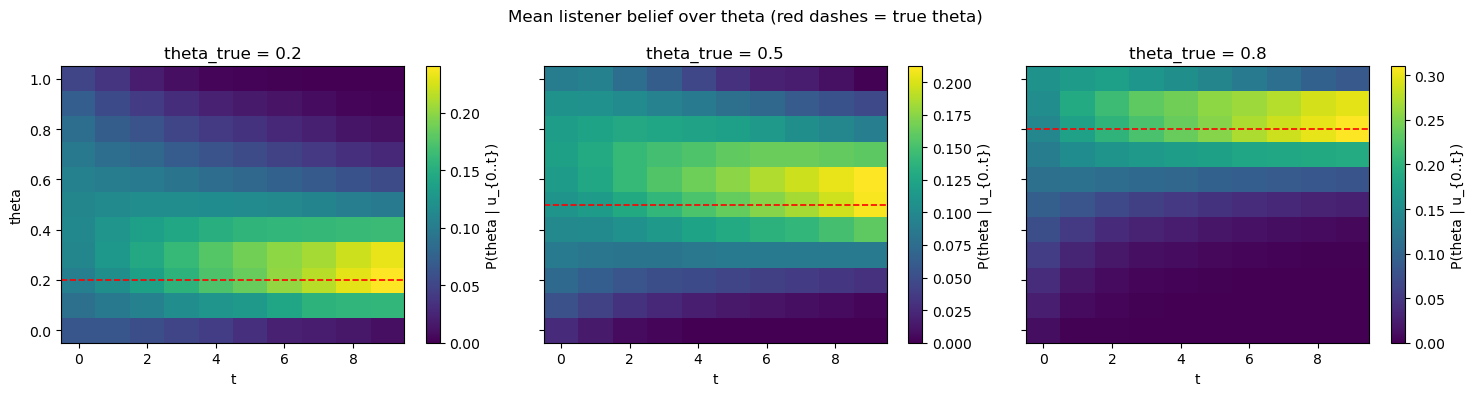

In [205]:
mean_bt = belief_ds.belief_theta.mean(['obs_idx', 'utt_idx'])  # (theta_true, t, theta)

fig, axes = plt.subplots(1, len(THETAS), figsize=(5 * len(THETAS), 4), sharey=True)
for ax, theta_t in zip(axes, THETAS):
    arr = mean_bt.sel(theta_true=theta_t).values  # (t, theta)
    im = ax.imshow(
        arr.T, aspect='auto', origin='lower',
        extent=[-0.5, T - 0.5, theta_grid[0] - 0.05, theta_grid[-1] + 0.05],
        cmap='viridis', vmin=0, vmax=arr.max(),
    )
    ax.axhline(theta_t, color='red', linestyle='--', linewidth=1.2)
    ax.set_title(f'theta_true = {theta_t}')
    ax.set_xlabel('t')
    if ax is axes[0]:
        ax.set_ylabel('theta')
    plt.colorbar(im, ax=ax, label='P(theta | u_{0..t})')
fig.suptitle('Mean listener belief over theta (red dashes = true theta)')
plt.tight_layout()
plt.show()

## 7. Plot 2 — `belief_psi` over t

Speaker is `pers+`. With enough utterances, the listener should put increasing mass on `pers+` and decreasing mass on the other two.

If this curve is flat at 1/3 it means the speaker's behavior under `pers+` is indistinguishable from the other psi choices for the listener — which can happen at certain theta values where all psi types produce similar utterance distributions.

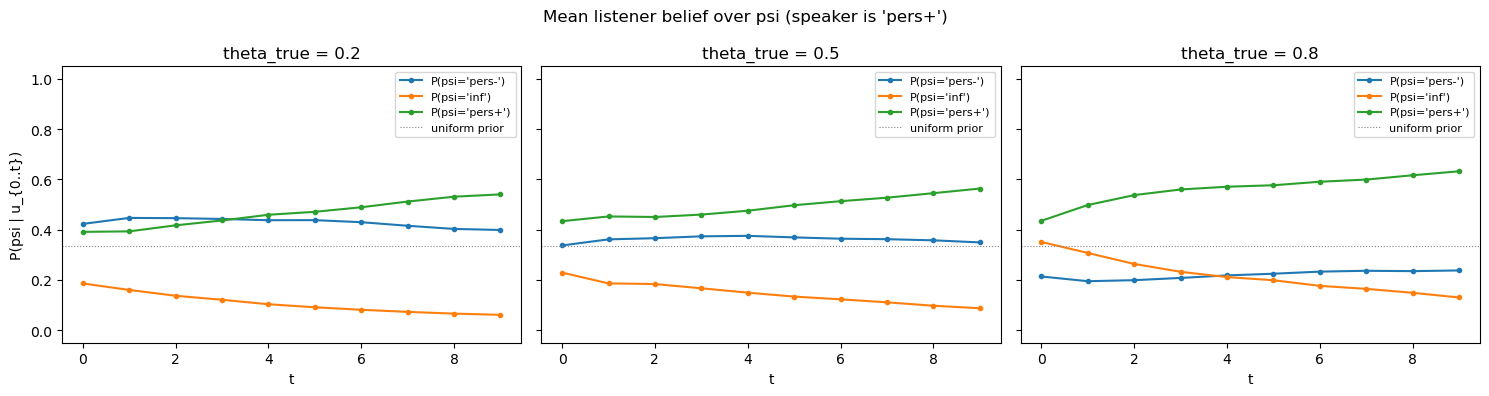

In [206]:
mean_bp = belief_ds.belief_psi.mean(['obs_idx', 'utt_idx'])  # (theta_true, t, psi)

fig, axes = plt.subplots(1, len(THETAS), figsize=(5 * len(THETAS), 4), sharey=True)
for ax, theta_t in zip(axes, THETAS):
    for psi_val in psi_grid:
        ax.plot(
            range(T),
            mean_bp.sel(theta_true=theta_t, psi=psi_val).values,
            label=f"P(psi='{psi_val}')", marker='o', markersize=3,
        )
    ax.axhline(1/3, color='gray', linestyle=':', linewidth=0.8, label='uniform prior')
    ax.set_title(f'theta_true = {theta_t}')
    ax.set_xlabel('t')
    if ax is axes[0]:
        ax.set_ylabel('P(psi | u_{0..t})')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='best', fontsize=8)
fig.suptitle("Mean listener belief over psi (speaker is 'pers+')")
plt.tight_layout()
plt.show()

## 8. L0 vs L1 listener comparison

Re-run Stage 3 with a literal listener (no pragmatic inference). Side-by-side belief heatmaps to see whether modeling the speaker's `pers+` bias actually helps the listener recover theta.

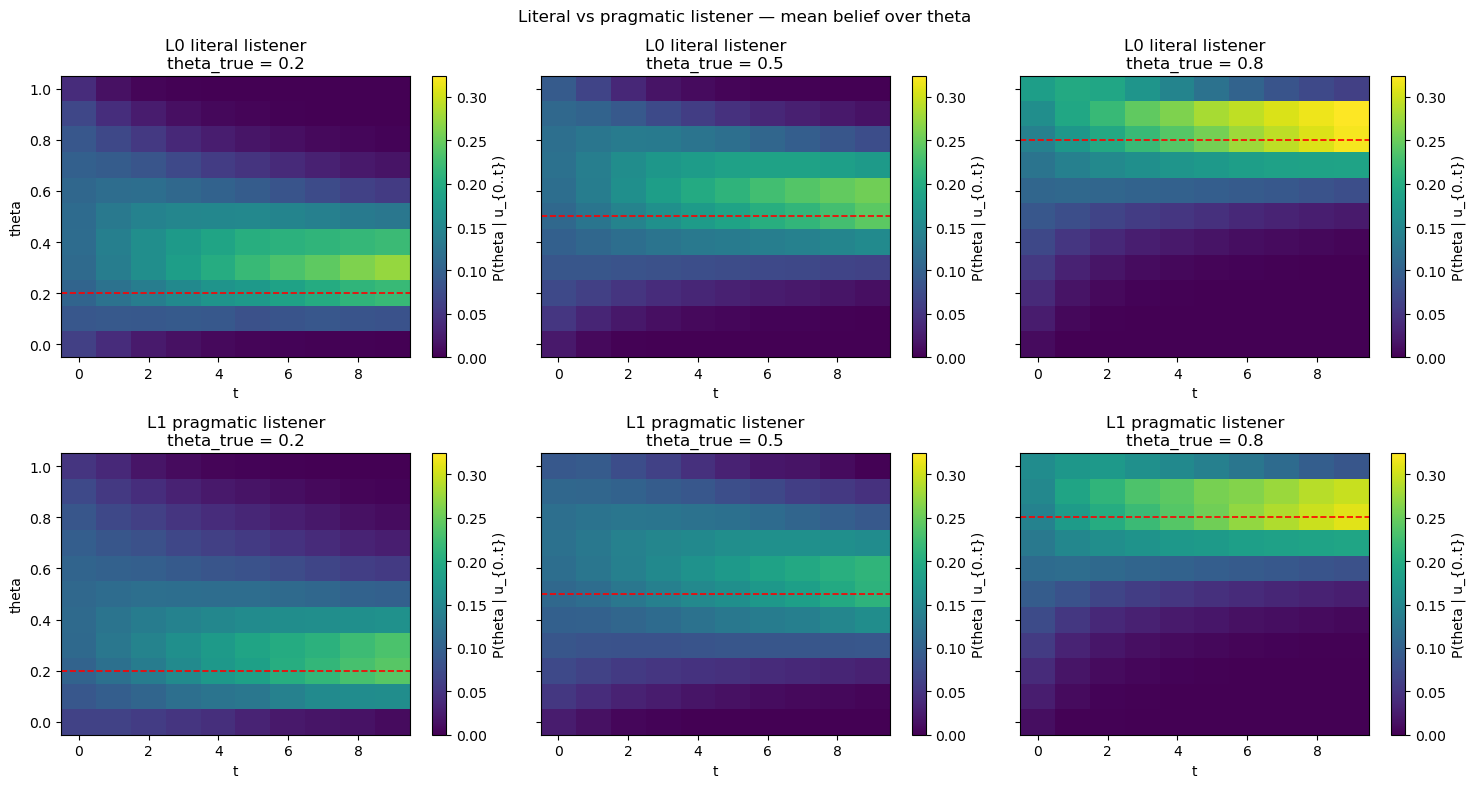

In [207]:
belief_ds_L0 = compute_listener_beliefs(utt_ds, world, {'listener': {'level': 0}})
mean_bt_L0 = belief_ds_L0.belief_theta.mean(['obs_idx', 'utt_idx'])  # (theta_true, t, theta)

fig, axes = plt.subplots(2, len(THETAS), figsize=(5 * len(THETAS), 8), sharey=True)
panels = [('L0 literal listener', mean_bt_L0), ('L1 pragmatic listener', mean_bt)]
vmax = max(mean_bt_L0.max().item(), mean_bt.max().item())
for col, theta_t in enumerate(THETAS):
    for row, (label, mbt) in enumerate(panels):
        arr = mbt.sel(theta_true=theta_t).values
        ax = axes[row, col]
        im = ax.imshow(
            arr.T, aspect='auto', origin='lower',
            extent=[-0.5, T - 0.5, theta_grid[0] - 0.05, theta_grid[-1] + 0.05],
            cmap='viridis', vmin=0, vmax=vmax,
        )
        ax.axhline(theta_t, color='red', linestyle='--', linewidth=1.2)
        ax.set_title(f'{label}\ntheta_true = {theta_t}')
        ax.set_xlabel('t')
        if col == 0:
            ax.set_ylabel('theta')
        plt.colorbar(im, ax=ax, label='P(theta | u_{0..t})')
fig.suptitle('Literal vs pragmatic listener — mean belief over theta')
plt.tight_layout()
plt.show()

## What to look for

1. **Plot 1** — does the heatmap row centered on `theta_true` brighten over t? If yes, the listener is recovering theta from utterances.
2. **Plot 2** — does `P(psi='pers+')` rise above 1/3? If yes, pragmatic inference is identifying the speaker's goal. If it stays flat, the speaker's pers+ utterances at this theta look the same as inf or pers- utterances would — informative if so.
3. **Plot 8** — does L1 give visibly sharper / more correctly centered belief than L0? That's the win for modeling the speaker explicitly.

Try editing the config above (different `psi`, `alpha`, `beta`, larger T, different listener config) and re-running.